In [4]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
from sklearn.preprocessing import StandardScaler
from utils import train, validate

In [5]:
print(f"Is CUDA available? {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Is CUDA available? True
GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU


In [6]:
train_df = pd.read_csv('data/train.csv')
val_df = pd.read_csv('data/test.csv')

x_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values
x_val = val_df.drop('label', axis=1).values
y_val = val_df['label'].values

print(y_val)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 

In [7]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

In [35]:
x_train_t = torch.tensor(x_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

x_val_t = torch.tensor(x_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

print(y_train_t.min(), y_train_t.max())
print(y_val_t.min(), y_val_t.max())

tensor(0.) tensor(1.)
tensor(0.) tensor(1.)


In [36]:
BATCH_SIZE = 32
train_ds = TensorDataset(x_train_t, y_train_t)
val_ds = TensorDataset(x_val_t, y_val_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

In [37]:
model = nn.Sequential(
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 1)
)
model = model.to(device)
model

Sequential(
  (0): Linear(in_features=1024, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.4, inplace=False)
  (3): Linear(in_features=512, out_features=128, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=128, out_features=1, bias=True)
)

In [38]:
num_negative = (train_df['label'] == 0).sum()
num_positive = (train_df['label'] == 1).sum()
pos_weight = torch.tensor(num_negative / num_positive)
loss_function = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [39]:
epochs = 20
threshold = 0.5
best_val_loss = float('inf')
patience = 5
counter = 0

for epoch in range(50):
    train(model, loss_function, threshold, optimizer, train_loader, device)
    val_loss = validate(model, loss_function, threshold, val_loader, device)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

# Load best model
model.load_state_dict(torch.load('best_model.pth'))

Train - Loss: 11.0010 Accuracy: 0.9457
Valid - Loss: 10.0926 Accuracy: 0.8333
Train - Loss: 5.7002 Accuracy: 0.9718
Valid - Loss: 10.9249 Accuracy: 0.8686
Train - Loss: 4.0576 Accuracy: 0.9810
Valid - Loss: 19.6635 Accuracy: 0.8157
Train - Loss: 3.5523 Accuracy: 0.9833
Valid - Loss: 13.5498 Accuracy: 0.8606
Train - Loss: 2.5674 Accuracy: 0.9893
Valid - Loss: 27.5078 Accuracy: 0.8029
Train - Loss: 2.0227 Accuracy: 0.9910
Valid - Loss: 23.4922 Accuracy: 0.8333
Train - Loss: 2.1929 Accuracy: 0.9918
Valid - Loss: 21.1618 Accuracy: 0.8365
Train - Loss: 1.9786 Accuracy: 0.9916
Valid - Loss: 26.2772 Accuracy: 0.8333
Train - Loss: 1.4647 Accuracy: 0.9937
Valid - Loss: 21.5980 Accuracy: 0.8606
Train - Loss: 1.1070 Accuracy: 0.9952
Valid - Loss: 38.2155 Accuracy: 0.8061
Train - Loss: 1.2678 Accuracy: 0.9944
Valid - Loss: 28.7364 Accuracy: 0.8205
Train - Loss: 1.2235 Accuracy: 0.9939
Valid - Loss: 31.1854 Accuracy: 0.8221
Train - Loss: 0.8311 Accuracy: 0.9960
Valid - Loss: 30.8366 Accuracy: 0.846

<All keys matched successfully>

In [40]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

test_df = pd.read_csv('data/test.csv')
x_test = test_df.drop('label', axis=1).values
y_test = test_df['label'].values

scaler = StandardScaler()
x_test = scaler.fit_transform(x_test)

In [41]:
import numpy as np
indices = np.random.choice(len(x_test), 500, replace=False)
x_sample = x_test[indices]
y_sample = y_test[indices]

In [42]:
import torch
x_tensor = torch.tensor(x_sample, dtype=torch.float32).to(device)
with torch.no_grad():
    output = model(x_tensor)
    probs = torch.sigmoid(output).cpu().numpy().flatten()
    preds = (probs > threshold).astype(int)

In [43]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_sample, preds))
print(classification_report(y_sample, preds, target_names=['NORMAL', 'PNEUMONIA']))

[[ 96  88]
 [  4 312]]
              precision    recall  f1-score   support

      NORMAL       0.96      0.52      0.68       184
   PNEUMONIA       0.78      0.99      0.87       316

    accuracy                           0.82       500
   macro avg       0.87      0.75      0.77       500
weighted avg       0.85      0.82      0.80       500



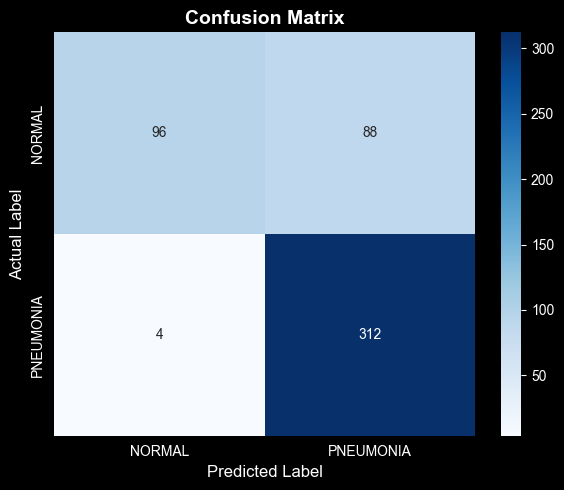

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_sample, preds)

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])

plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [8]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=42
)
svm.fit(x_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


              precision    recall  f1-score   support

      NORMAL       0.98      0.59      0.74       234
   PNEUMONIA       0.80      0.99      0.89       390

    accuracy                           0.84       624
   macro avg       0.89      0.79      0.81       624
weighted avg       0.87      0.84      0.83       624



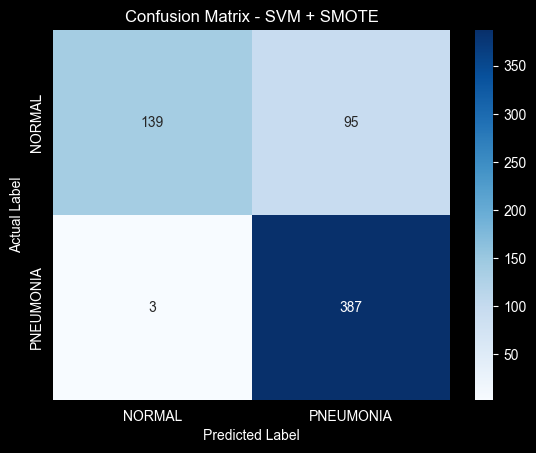

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

preds = svm.predict(x_val)

print(classification_report(y_val, preds, target_names=['NORMAL', 'PNEUMONIA']))

cm = confusion_matrix(y_val, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])
plt.title('Confusion Matrix - SVM')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [45]:
# import IPython
# app = IPython.Application.instance()
# app.kernel.do_shutdown(True)